# 4a - Modelli Studente A: KNN e Random Forest

Questo notebook implementa e ottimizza due classificatori:

1. K-Nearest Neighbors (KNN);
2. Random Forest Classifier.

I modelli vengono addestrati esclusivamente sul Training Set prodotto
durante la fase di Data Preparation.

La selezione degli iperparametri viene effettuata mediante Grid Search
con 5-Fold Stratified Cross-Validation.

Il Test Set rimane completamente separato e verrà utilizzato esclusivamente
per la valutazione finale dei modelli.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Keep Out\File\Magistrale\predictLoL


## 1. Caricamento del Training Set

Vengono caricati esclusivamente il Training Set standardizzato e la
corrispondente variabile target.

Il Test Set non viene utilizzato durante l'ottimizzazione e
l'addestramento dei modelli.

In [3]:
X_TRAIN_PATH = PROJECT_ROOT / "data" / "X_train_scaled.csv"
Y_TRAIN_PATH = PROJECT_ROOT / "data" / "y_train.csv"

assert X_TRAIN_PATH.exists(), f"File non trovato: {X_TRAIN_PATH}"
assert Y_TRAIN_PATH.exists(), f"File non trovato: {Y_TRAIN_PATH}"

X_train = pd.read_csv(X_TRAIN_PATH)
y_train = pd.read_csv(Y_TRAIN_PATH)["blueWins"]

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

X_train: (7903, 27)
y_train: (7903,)


In [4]:
print(f"Valori mancanti in X_train: {X_train.isna().sum().sum()}")
print(f"Valori mancanti in y_train: {y_train.isna().sum()}")

print("\nDistribuzione target:")
print(y_train.value_counts())

Valori mancanti in X_train: 0
Valori mancanti in y_train: 0

Distribuzione target:
blueWins
0    3959
1    3944
Name: count, dtype: int64


In [5]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## 2. K-Nearest Neighbors

K-Nearest Neighbors classifica una nuova osservazione considerando
le classi delle osservazioni più vicine nello spazio delle feature.

La Grid Search viene utilizzata per ottimizzare:

- il numero di vicini `n_neighbors`;
- la metrica di distanza;
- il metodo di pesatura dei vicini.

In [6]:
knn_model = KNeighborsClassifier()

knn_param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15],
    "metric": ["euclidean", "manhattan"],
    "weights": ["uniform", "distance"]
}

knn_grid = GridSearchCV(
    estimator=knn_model,
    param_grid=knn_param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)

print("Grid Search KNN completata.")

Grid Search KNN completata.


In [7]:
print("Migliori iperparametri KNN:")
print(knn_grid.best_params_)

print(
    f"\nMigliore accuracy media in Cross-Validation: "
    f"{knn_grid.best_score_:.4f}"
)

best_knn_model = knn_grid.best_estimator_

Migliori iperparametri KNN:
{'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'uniform'}

Migliore accuracy media in Cross-Validation: 0.7150


In [8]:
best_knn_model = knn_grid.best_estimator_
print(best_knn_model)

KNeighborsClassifier(metric='manhattan', n_neighbors=15)


### Importanza della standardizzazione per KNN

K-Nearest Neighbors è un algoritmo basato sul calcolo delle distanze
tra le osservazioni nello spazio delle feature.

Nel caso della distanza euclidea, la distanza tra due osservazioni
$x$ e $y$ è:

$$
d(x,y) = \sqrt{\sum_{i=1}^{n}(x_i-y_i)^2}
$$

Se le feature presentassero scale numeriche molto differenti, le variabili
caratterizzate da valori numericamente più elevati potrebbero dominare
il calcolo della distanza.

Ad esempio, una feature economica come l'oro può assumere valori molto
più elevati rispetto a feature discrete o binarie relative agli obiettivi
di gioco. Senza standardizzazione, la distanza tra due partite sarebbe
quindi influenzata principalmente dalle feature con range numerico maggiore.

L'utilizzo dello Z-Score porta invece le feature su scale confrontabili:

$$
z = \frac{x-\mu}{\sigma}
$$

dove $\mu$ rappresenta la media e $\sigma$ la deviazione standard calcolate
sul Training Set.

La standardizzazione è quindi fondamentale per KNN affinché tutte le
feature possano contribuire in maniera comparabile al calcolo delle distanze.

Per prevenire data leakage, i parametri dello scaling sono stati calcolati
esclusivamente sul Training Set durante la fase di Data Preparation.

## 3. Random Forest Classifier

Random Forest è un metodo ensemble basato sul bagging che combina
le predizioni di molteplici alberi decisionali.

Ogni albero viene addestrato su un campione dei dati e considera
un sottoinsieme delle feature durante la scelta degli split.

La Grid Search viene utilizzata per ottimizzare:

- numero di alberi (`n_estimators`);
- profondità massima (`max_depth`);
- numero di feature considerate ad ogni split (`max_features`).

In [9]:
random_forest_model = RandomForestClassifier(
    random_state=42
)

random_forest_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, None],
    "max_features": ["sqrt", "log2", None]
}

random_forest_grid = GridSearchCV(
    estimator=random_forest_model,
    param_grid=random_forest_param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

random_forest_grid.fit(X_train, y_train)

print("Grid Search Random Forest completata.")

Grid Search Random Forest completata.


In [10]:
print("Migliori iperparametri Random Forest:")
print(random_forest_grid.best_params_)

print(
    f"\nMigliore accuracy media in Cross-Validation: "
    f"{random_forest_grid.best_score_:.4f}"
)

best_random_forest_model = random_forest_grid.best_estimator_

Migliori iperparametri Random Forest:
{'max_depth': 5, 'max_features': 'log2', 'n_estimators': 100}

Migliore accuracy media in Cross-Validation: 0.7321


In [11]:
print(best_random_forest_model)

RandomForestClassifier(max_depth=5, max_features='log2', random_state=42)


In [12]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance

,feature,importance
13,blueGoldDiff,0.222395
14,blueExperienceDiff,0.169296
8,blueTotalGold,0.092707
21,redTotalGold,0.087704
15,blueGoldPerMin,0.077175
23,redTotalExperience,0.074265
26,redGoldPerMin,0.063139
9,blueAvgLevel,0.044893
10,blueTotalExperience,0.038871
22,redAvgLevel,0.029249


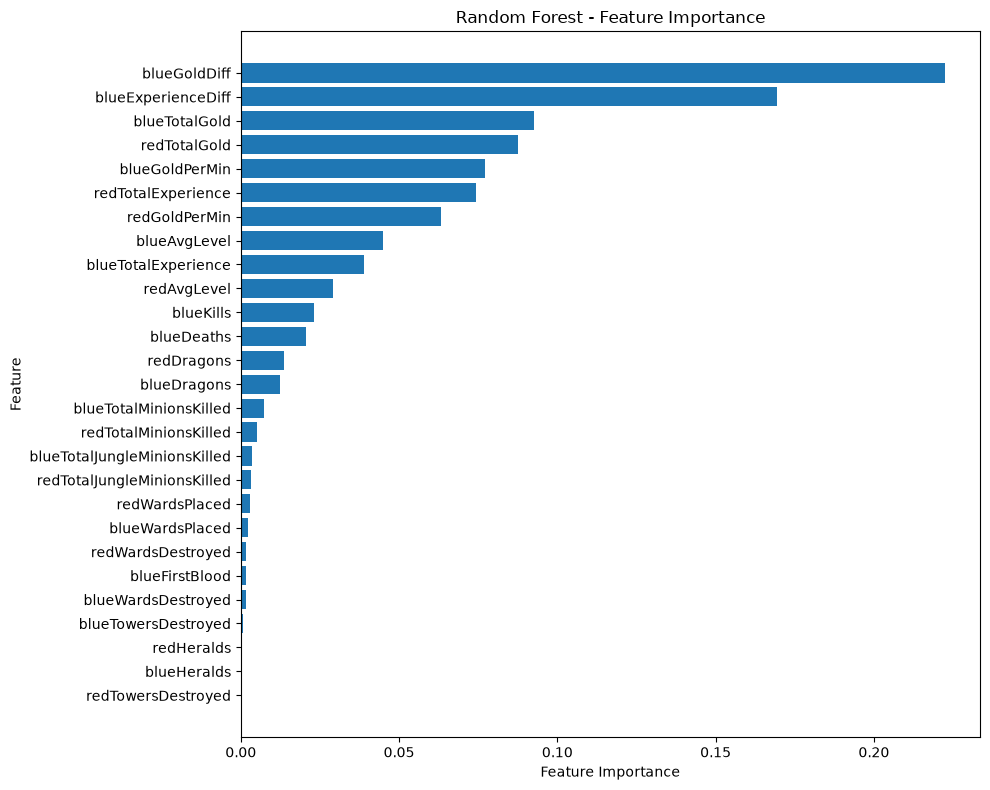

In [13]:
plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest - Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Interpretazione della Feature Importance

La Random Forest assegna a ciascuna feature un valore di importanza
che rappresenta il contributo relativo della variabile alle decisioni
effettuate dagli alberi dell'ensemble.

Valori di importanza più elevati indicano feature maggiormente utilizzate
dal modello per produrre split utili alla classificazione.

Le feature importance permettono quindi di individuare quali statistiche
di gioco risultano maggiormente informative per la previsione di
`blueWins`.

## 4. Salvataggio dei modelli

I migliori modelli individuati tramite Grid Search vengono salvati
nella cartella `models/` mediante `joblib`, in modo da poter essere
utilizzati successivamente senza ripetere l'addestramento.

In [14]:
MODELS_DIR = PROJECT_ROOT / "models"

MODELS_DIR.mkdir(parents=True, exist_ok=True)

KNN_MODEL_PATH = MODELS_DIR / "knn_best.pkl"
RANDOM_FOREST_MODEL_PATH = MODELS_DIR / "random_forest_best.pkl"

joblib.dump(best_knn_model, KNN_MODEL_PATH)
joblib.dump(best_random_forest_model, RANDOM_FOREST_MODEL_PATH)

print(f"KNN salvato in: {KNN_MODEL_PATH}")
print(f"Random Forest salvata in: {RANDOM_FOREST_MODEL_PATH}")

KNN salvato in: c:\Keep Out\File\Magistrale\predictLoL\models\knn_best.pkl
Random Forest salvata in: c:\Keep Out\File\Magistrale\predictLoL\models\random_forest_best.pkl


## Controllo finale

In [15]:
print("Controllo file salvati:")

print(
    f"{'OK' if KNN_MODEL_PATH.exists() else 'ERRORE'} "
    f"- {KNN_MODEL_PATH.name}"
)

print(
    f"{'OK' if RANDOM_FOREST_MODEL_PATH.exists() else 'ERRORE'} "
    f"- {RANDOM_FOREST_MODEL_PATH.name}"
)

Controllo file salvati:
OK - knn_best.pkl
OK - random_forest_best.pkl
